# Desafio Técnico — Engenharia de Dados

Marketplace B2B de distribuição de alimentos. O objetivo é resolver, via SQL, as
inconsistências que estão travando as decisões do time de negócios.

**Stack:** `pandas` + `pandasql` (SQLite como motor SQL sobre os DataFrames), conforme o
notebook modelo fornecido.

| Seção | Conteúdo |
|---|---|
| 0 | Setup e carga dos dados |
| 1 | Auditoria da base (profiling) — o que descobrimos antes de escrever qualquer query |
| 2 | **Desafio 1** — Faturamento bruto mensal dos últimos 12 meses |
| 3 | Desafio 2 — Ranking de crescimento de GMV por seller |
| 4 | Desafio 3 — Pedidos com desconto abusivo |
| 5 | Desafio 4 — Produtos que nunca são o item de maior valor |

## 0. Setup e carga dos dados

In [1]:
# No Google Colab, descomente a linha abaixo:
# !pip install -q pandasql

In [2]:
import warnings
from pathlib import Path

import pandas as pd
from pandasql import sqldf

warnings.filterwarnings('ignore')

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

# Executa SQL sobre os DataFrames do escopo global.
pysqldf = lambda q: sqldf(q, globals())

In [3]:
# Resolve o diretório dos CSVs tanto no Colab (/content) quanto em execução local.
CANDIDATOS = [Path('dados'), Path('../dados'), Path('/content'), Path('/content/dados')]
DADOS = next((p for p in CANDIDATOS if (p / 'orders.csv').exists()), None)

if DADOS is None:
    raise FileNotFoundError(
        'CSVs não encontrados. Ajuste a lista CANDIDATOS ou faça upload dos arquivos '
        'para /content no Colab.'
    )

buyers      = pd.read_csv(DADOS / 'buyers.csv',      sep=',')
order_items = pd.read_csv(DADOS / 'order_items.csv', sep=',')
orders      = pd.read_csv(DADOS / 'orders.csv',      sep=',')
payments    = pd.read_csv(DADOS / 'payments.csv',    sep=',')
products    = pd.read_csv(DADOS / 'products.csv',    sep=',')
sellers     = pd.read_csv(DADOS / 'sellers.csv',     sep=',')

print(f'Dados carregados de: {DADOS.resolve()}\n')
for nome, df in [('buyers', buyers), ('order_items', order_items), ('orders', orders),
                 ('payments', payments), ('products', products), ('sellers', sellers)]:
    print(f'{nome:<12} {len(df):>7,} linhas  |  colunas: {list(df.columns)}')

Dados carregados de: /mnt/d/Users/renat/Downloads/Teste Engenheiro de Dados (1)/Teste Engenheiro de Dados/dados

buyers         3,001 linhas  |  colunas: ['id', 'name', 'city', 'state', 'segment', 'created_at']
order_items  214,768 linhas  |  colunas: ['id', 'order_id', 'product_id', 'qty', 'unit_price', 'discount']
orders        80,002 linhas  |  colunas: ['id', 'seller_id', 'buyer_id', 'status', 'created_at', 'total_value']
payments      80,000 linhas  |  colunas: ['id', 'order_id', 'paid_at', 'amount', 'method', 'status']
products         800 linhas  |  colunas: ['id', 'name', 'category', 'seller_id', 'active', 'unit_cost']
sellers          120 linhas  |  colunas: ['id', 'name', 'state', 'plan', 'created_at']


## 1. Auditoria da base

Antes de escrever a query do faturamento, precisamos saber **em que podemos confiar**.
Esta seção documenta os problemas encontrados — cada um deles influencia diretamente as
decisões tomadas nas queries seguintes.

In [4]:
# 1.1 — Quais status existem e qual o volume de cada um?
# Também verificamos variações de casing/espaços, que quebrariam um filtro literal.
pysqldf('''
    SELECT status,
           COUNT(*)                    AS qtd_pedidos,
           ROUND(SUM(total_value), 2)  AS valor_total,
           MIN(created_at)             AS primeiro_pedido,
           MAX(created_at)             AS ultimo_pedido
    FROM orders
    GROUP BY status
    ORDER BY qtd_pedidos DESC
''')

,status,qtd_pedidos,valor_total,primeiro_pedido,ultimo_pedido
0,completed,32047,"509,029,365.76",2023-08-01 00:33:08,2024-11-29 23:27:22
1,delivered,28030,"440,939,417.11",2023-08-01 00:35:28,2024-11-29 23:35:22
2,processing,7974,"125,601,188.75",2023-08-01 00:30:25,2024-11-29 23:32:08
3,cancelled,7963,"126,251,011.13",2023-08-01 02:55:17,2024-11-29 23:37:25
4,refunded,3988,"62,486,517.64",2023-08-01 02:59:16,2024-11-29 21:42:02


**Achado 1 — a base é um snapshot histórico.**
O pedido mais recente é de **2024-11-29**. Uma query que ancore os "últimos 12 meses" em
`DATE('now')` retornaria **zero linhas**. A janela precisa ser ancorada na data máxima
observada nos dados (e parametrizada, para virar `now` em produção).

In [5]:
# 1.2 — Integridade das chaves: existe pedido duplicado? chave órfã? valor nulo/negativo?
pysqldf('''
    SELECT COUNT(*)                       AS linhas,
           COUNT(DISTINCT id)             AS ids_distintos,
           COUNT(*) - COUNT(DISTINCT id)  AS linhas_duplicadas,
           SUM(created_at  IS NULL)       AS datas_nulas,
           SUM(total_value IS NULL)       AS valores_nulos,
           SUM(total_value <= 0)          AS valores_nao_positivos
    FROM orders
''')

,linhas,ids_distintos,linhas_duplicadas,datas_nulas,valores_nulos,valores_nao_positivos
0,80002,80000,2,0,0,0


In [6]:
# 1.3 — Inspeção das duplicatas: mesma PK, conteúdo levemente diferente.
pysqldf('''
    SELECT *
    FROM orders
    WHERE id IN (SELECT id FROM orders GROUP BY id HAVING COUNT(*) > 1)
    ORDER BY id, created_at
''')

,id,seller_id,buyer_id,status,created_at,total_value
0,79990,79,1070,processing,2024-08-13 19:00:10,"12,162.98"
1,79990,79,1070,processing,2024-08-15 19:00:10,"12,165.99"
2,79991,4,153,refunded,2024-11-13 09:53:35,"1,670.88"
3,79991,4,153,refunded,2024-11-18 09:53:35,"1,610.87"


**Achado 2 — há 2 pedidos com `id` duplicado** (`79990` e `79991`).

Mesmo `seller_id`, `buyer_id` e `status`, mas `created_at` e `total_value` diferentes —
assinatura clássica de **reingestão / CDC sem deduplicação**. Nenhum dos dois está em
`completed`/`delivered`, então não contaminam o Desafio 1 hoje; mas a query precisa ser
robusta a isso, porque no próximo carregamento a duplicata pode cair num status faturável.

Critério adotado: manter a **versão mais recente** de cada `id` (`ROW_NUMBER()` particionado
por `id`, ordenado por `created_at DESC`).

In [7]:
# 1.4 — O status do pedido é consistente com o status do pagamento?
# Se não fosse, o filtro por status de pedido seria insuficiente e precisaríamos
# cruzar com payments para definir faturamento.
pysqldf('''
    SELECT o.status                              AS status_pedido,
           COALESCE(p.status, 'SEM_PAGAMENTO')   AS status_pagamento,
           COUNT(*)                              AS qtd
    FROM orders AS o
    LEFT JOIN payments AS p ON p.order_id = o.id
    GROUP BY 1, 2
    ORDER BY 1, 3 DESC
''')

,status_pedido,status_pagamento,qtd
0,cancelled,failed,3944
1,cancelled,refunded,2344
2,cancelled,pending,1675
3,completed,paid,32047
4,delivered,paid,28030
5,processing,paid,7974
6,refunded,refunded,3988


**Achado 3 — status de pedido e de pagamento estão 100% alinhados.**

`completed` e `delivered` correspondem *sempre* a pagamento `paid`; `cancelled` nunca tem
pagamento efetivado e `refunded` sempre tem estorno. Não há pedido entregue com pagamento
falho.

Consequência prática: **filtrar por `orders.status` é suficiente** para o faturamento.
Adicionar um `JOIN` com `payments` não mudaria nenhum número e só encareceria a query —
mas foi preciso *verificar* isso antes de decidir.

In [8]:
# 1.5 — De onde vem o total_value? Ele bate com a soma dos itens?
# Isso define o que é "faturamento bruto".
pysqldf('''
    WITH itens_por_pedido AS (
        SELECT order_id,
               SUM(qty * unit_price)                             AS bruto_sem_desconto,
               SUM(qty * unit_price - COALESCE(discount, 0))      AS liquido_de_desconto
        FROM order_items
        GROUP BY order_id
    )
    SELECT COUNT(*)                                                  AS pedidos_com_itens,
           SUM(ABS(o.total_value - i.liquido_de_desconto) < 0.02)    AS batem_com_liquido,
           SUM(ABS(o.total_value - i.bruto_sem_desconto)  < 0.02)    AS batem_com_bruto
    FROM orders AS o
    JOIN itens_por_pedido AS i ON i.order_id = o.id
''')

,pedidos_com_itens,batem_com_liquido,batem_com_bruto
0,80002,80000,0


**Achado 4 — `orders.total_value` é a soma dos itens já líquida de desconto**
(bate em 80.000 dos 80.002 registros; as 2 exceções são exatamente as linhas duplicadas).

Todo pedido tem ao menos um item, e não há chave órfã entre `orders`, `order_items`,
`products`, `sellers` e `buyers`. `total_value` é, portanto, uma fonte confiável e
pré-agregada para o faturamento — evita um `JOIN` de 214k linhas sem ganho de precisão.

---
## 2. Desafio 1 — Faturamento bruto mensal (últimos 12 meses)

> *"O time financeiro reclama que o total de faturamento mensal varia dependendo de quem
> puxa o relatório. Pedidos com status `cancelled` e `refunded` estão sendo incluídos em
> alguns relatórios."*

**Pedido:** faturamento bruto mensal dos últimos 12 meses, apenas pedidos `completed` ou
`delivered`, com quantidade de pedidos e ticket médio, do mês mais recente ao mais antigo.

### Decisões de modelagem

| Ponto | Decisão | Por quê |
|---|---|---|
| Janela de 12 meses | Ancorada em `MAX(created_at)`, não em `DATE('now')` | A base termina em 2024-11-29; `now` devolveria zero linhas (Achado 1) |
| Recorte da janela | 12 meses-calendário fechados: 2023-12 a 2024-11 | Relatório mensal do financeiro compara meses inteiros; uma janela móvel de 365 dias produziria dois meses parciais nas pontas |
| Definição de "bruto" | `SUM(total_value)` = GMV do pedido | "Bruto" aqui se opõe a *líquido de cancelamentos/estornos* — que é exatamente o que o filtro de status resolve. O desconto comercial já está aplicado no preço praticado |
| Deduplicação | `ROW_NUMBER()` por `id`, versão mais recente | Achado 2 |
| Filtro de status | `LOWER(TRIM(status))` | Defesa contra variação de casing/espaço na origem |
| Ticket médio | `SUM(total_value) / NULLIF(COUNT(*), 0)` | `NULLIF` elimina o risco de divisão por zero |
| Data de referência | `orders.created_at` (data do pedido) | O financeiro pede faturamento *por mês do pedido*; usar `payments.paid_at` mediria regime de caixa, não competência |

In [9]:
desafio_1 = '''
WITH parametros AS (
    -- A base é um snapshot histórico (último pedido: 2024-11-29). Ancorar a janela em
    -- DATE('now') devolveria zero linhas, então usamos o mês mais recente dos dados.
    -- Em produção, substituir por: strftime('%Y-%m', 'now')
    SELECT strftime('%Y-%m', MAX(created_at)) AS mes_referencia
    FROM orders
),

pedidos_deduplicados AS (
    -- orders traz ids repetidos por reingestão; mantemos a versão mais recente de cada id.
    SELECT id, status, created_at, total_value
    FROM (
        SELECT o.id,
               o.status,
               o.created_at,
               o.total_value,
               ROW_NUMBER() OVER (
                   PARTITION BY o.id
                   ORDER BY o.created_at DESC
               ) AS versao
        FROM orders AS o
    )
    WHERE versao = 1
),

pedidos_faturados AS (
    -- Regra de negócio: só compõe faturamento o pedido completed ou delivered.
    -- LOWER/TRIM protege contra variação de casing e espaços vindos da origem.
    SELECT strftime('%Y-%m', p.created_at) AS mes,
           p.total_value
    FROM pedidos_deduplicados AS p
    CROSS JOIN parametros AS par
    WHERE LOWER(TRIM(p.status)) IN ('completed', 'delivered')
      AND p.created_at  IS NOT NULL
      AND p.total_value IS NOT NULL
      -- Janela de 12 meses-calendário fechados terminando no mês de referência.
      AND strftime('%Y-%m', p.created_at) <= par.mes_referencia
      AND strftime('%Y-%m', p.created_at) >  strftime(
              '%Y-%m', DATE(par.mes_referencia || '-01', '-12 months')
          )
)

SELECT mes,
       COUNT(*)                                          AS qtd_pedidos,
       ROUND(SUM(total_value), 2)                        AS faturamento_bruto,
       -- NULLIF evita divisão por zero caso o mês não tenha pedidos elegíveis.
       ROUND(SUM(total_value) / NULLIF(COUNT(*), 0), 2)  AS ticket_medio
FROM pedidos_faturados
GROUP BY mes
ORDER BY mes DESC
'''

resultado_desafio1 = pysqldf(desafio_1)
resultado_desafio1

,mes,qtd_pedidos,faturamento_bruto,ticket_medio
0,2024-11,3643,"56,710,238.63","15,566.91"
1,2024-10,3863,"62,493,439.13","16,177.44"
2,2024-09,3779,"60,274,462.50","15,949.84"
3,2024-08,3743,"60,102,539.82","16,057.32"
4,2024-07,3862,"59,769,406.95","15,476.28"
5,2024-06,3644,"58,797,774.37","16,135.50"
6,2024-05,3848,"60,730,315.72","15,782.31"
7,2024-04,3653,"57,779,312.59","15,816.95"
8,2024-03,3877,"61,525,913.64","15,869.46"
9,2024-02,3628,"57,926,376.26","15,966.48"


### 2.1 Validação: qual era o tamanho do erro?

O ponto do desafio não é só produzir a query certa — é **quantificar o estrago** que o
relatório errado estava causando.

In [10]:
# Compara o número correto com as leituras equivocadas que circulavam na empresa,
# no mesmo período de 12 meses.
pysqldf('''
    SELECT ROUND(SUM(total_value), 2)                                                    AS a_todos_os_status,
           ROUND(SUM(CASE WHEN status IN ('completed','delivered') THEN total_value END), 2) AS b_faturamento_correto,
           ROUND(SUM(CASE WHEN status IN ('cancelled','refunded')  THEN total_value END), 2) AS c_nao_faturavel,
           ROUND(SUM(CASE WHEN status = 'processing'               THEN total_value END), 2) AS d_ainda_em_aberto
    FROM orders
    WHERE created_at >= '2023-12-01'
''')

,a_todos_os_status,b_faturamento_correto,c_nao_faturavel,d_ainda_em_aberto
0,"950,317,556.81","715,636,164.46","140,645,342.35","94,036,050.00"


In [11]:
# Impacto percentual do bug.
comparacao = pysqldf('''
    SELECT SUM(total_value)                                                        AS todos,
           SUM(CASE WHEN status IN ('completed','delivered') THEN total_value END) AS correto
    FROM orders
    WHERE created_at >= '2023-12-01'
''').iloc[0]

inflacao = comparacao.todos / comparacao.correto - 1
print(f'Relatório sem filtro de status : R$ {comparacao.todos:>18,.2f}')
print(f'Faturamento real (12 meses)    : R$ {comparacao.correto:>18,.2f}')
print(f'Diferença                      : R$ {comparacao.todos - comparacao.correto:>18,.2f}')
print(f'Superestimativa                : {inflacao:.1%}')

Relatório sem filtro de status : R$     950,317,556.81
Faturamento real (12 meses)    : R$     715,636,164.46
Diferença                      : R$     234,681,392.35
Superestimativa                : 32.8%


### 2.2 Leitura de negócio

Um detalhe importante para o time financeiro: **"desconsiderar cancelados" não é a mesma
coisa que "considerar apenas `completed` e `delivered`"**.

Os pedidos em `processing` não estão cancelados, mas também ainda não são receita
reconhecida. Quem filtrasse apenas `status NOT IN ('cancelled','refunded')` continuaria
com um número inflado — e provavelmente é essa a origem da divergência entre os relatórios
que circulam hoje: cada área está usando uma definição diferente de "pedido válido".

**Recomendação:** materializar essa regra numa view/tabela canônica
(`fct_pedidos_faturados`) para que ninguém mais precise reescrever o filtro à mão.

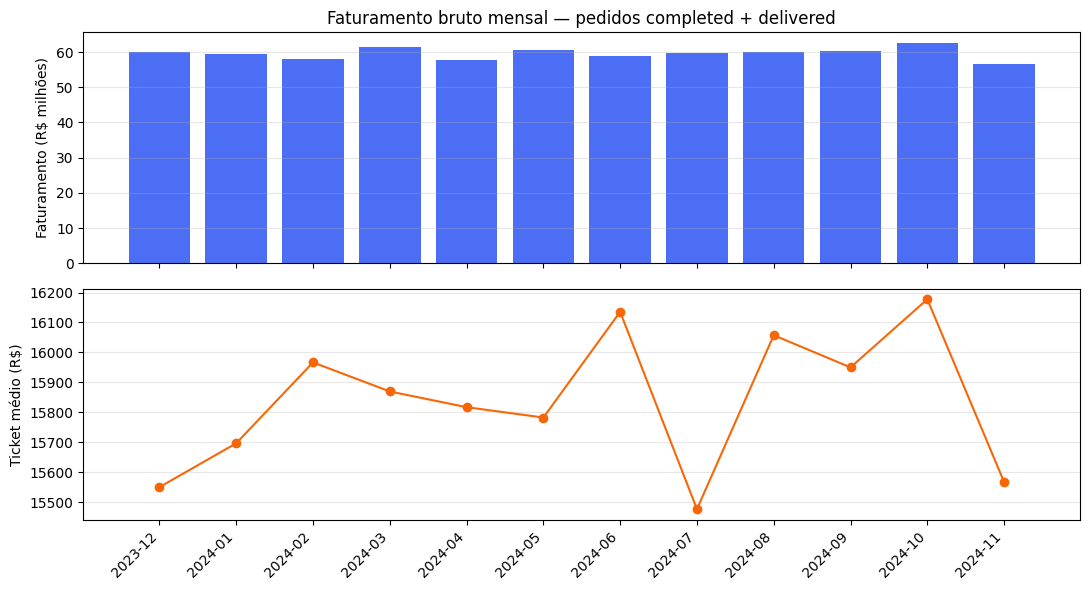

In [12]:
# Faturamento e ticket médio ao longo dos 12 meses.
import matplotlib.pyplot as plt

grafico = resultado_desafio1.sort_values('mes')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.bar(grafico.mes, grafico.faturamento_bruto / 1e6, color='#4C6EF5')
ax1.set_ylabel('Faturamento (R$ milhões)')
ax1.set_title('Faturamento bruto mensal — pedidos completed + delivered')
ax1.grid(axis='y', alpha=.3)

ax2.plot(grafico.mes, grafico.ticket_medio, marker='o', color='#F76707')
ax2.set_ylabel('Ticket médio (R$)')
ax2.grid(axis='y', alpha=.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

O faturamento é **notavelmente estável** ao longo dos 12 meses (R$ 56,7 mi – R$ 62,5 mi,
amplitude de ~10%), sem sazonalidade nem tendência de crescimento. Para um marketplace com
3 anos de operação e discurso de expansão, isso é em si um sinal a investigar — vale
confirmar com o time se a base é uma amostra sintética/parcial antes de usar esses números
em qualquer projeção.

---
## 3. Desafio 2 — Ranking de crescimento de GMV por seller

> *"A diretora comercial quer um ranking dos 10 sellers com maior crescimento de GMV entre o
> trimestre atual e o anterior, mas só quer ver sellers que tiveram pelo menos 50 pedidos em
> ambos os trimestres (para evitar distorção de sellers novos ou inativos)."*

**Pedido:** nome do seller, estado, GMV do trimestre anterior, GMV do trimestre atual e
percentual de crescimento, ordenado pelo maior crescimento.

### O problema escondido: qual é o "trimestre atual"?

A leitura ingênua seria usar o trimestre da última data da base — **2024-Q4**. Mas a base
termina em **29/11/2024**: esse trimestre tem apenas 2 dos 3 meses. Vamos medir o estrago
antes de decidir.

In [13]:
# Volume por trimestre — quantos meses cada um tem de fato?
pysqldf('''
    SELECT strftime('%Y', created_at) || '-Q' ||
               ((CAST(strftime('%m', created_at) AS INTEGER) + 2) / 3)  AS trimestre,
           COUNT(DISTINCT strftime('%Y-%m', created_at))                AS meses_com_dados,
           MIN(DATE(created_at))                                        AS primeiro_dia,
           MAX(DATE(created_at))                                        AS ultimo_dia,
           COUNT(*)                                                     AS pedidos,
           ROUND(SUM(total_value), 2)                                   AS gmv
    FROM orders
    WHERE status IN ('completed', 'delivered')
    GROUP BY 1
    ORDER BY 1
''')

,trimestre,meses_com_dados,primeiro_dia,ultimo_dia,pedidos,gmv
0,2023-Q3,2,2023-08-01,2023-09-30,7419,"116,426,239.53"
1,2023-Q4,3,2023-10-01,2023-12-31,11329,"177,959,510.58"
2,2024-Q1,3,2024-01-01,2024-03-31,11294,"178,925,543.05"
3,2024-Q2,3,2024-04-01,2024-06-30,11145,"177,307,402.68"
4,2024-Q3,3,2024-07-01,2024-09-30,11384,"180,146,409.27"
5,2024-Q4,2,2024-10-01,2024-11-29,7506,"119,203,677.76"


O primeiro e o último trimestre são **parciais**: 2023-Q3 começa em 01/08 e 2024-Q4 termina
em 29/11. Um trimestre cheio roda ~R$ 178 mi; o 2024-Q4 registra R$ 119 mi — não porque as
vendas caíram, mas porque falta um mês inteiro de dados.

Vamos confirmar o efeito disso no ranking pedido.

In [14]:
# O que aconteceria se usássemos 2024-Q4 (parcial) como "trimestre atual"?
pysqldf('''
    WITH pedidos_por_trimestre AS (
        SELECT seller_id, total_value,
               DATE(strftime('%Y', created_at) || '-' ||
                    printf('%02d', ((CAST(strftime('%m', created_at) AS INTEGER) - 1) / 3) * 3 + 1) ||
                    '-01') AS inicio_trimestre
        FROM orders
        WHERE status IN ('completed', 'delivered')
    ),
    comparativo AS (
        SELECT seller_id,
               SUM(  CASE WHEN inicio_trimestre = '2024-07-01' THEN total_value END) AS gmv_q3,
               COUNT(CASE WHEN inicio_trimestre = '2024-07-01' THEN 1 END)           AS ped_q3,
               SUM(  CASE WHEN inicio_trimestre = '2024-10-01' THEN total_value END) AS gmv_q4,
               COUNT(CASE WHEN inicio_trimestre = '2024-10-01' THEN 1 END)           AS ped_q4
        FROM pedidos_por_trimestre
        WHERE inicio_trimestre IN ('2024-07-01', '2024-10-01')
        GROUP BY seller_id
    )
    SELECT COUNT(*)                                            AS sellers_no_corte_50,
           SUM(100.0 * (gmv_q4 - gmv_q3) / gmv_q3 > 0)         AS com_crescimento_positivo,
           ROUND(MAX(100.0 * (gmv_q4 - gmv_q3) / gmv_q3), 2)   AS melhor_resultado_pct,
           ROUND(MIN(100.0 * (gmv_q4 - gmv_q3) / gmv_q3), 2)   AS pior_resultado_pct
    FROM comparativo
    WHERE ped_q3 >= 50 AND ped_q4 >= 50
''')

,sellers_no_corte_50,com_crescimento_positivo,melhor_resultado_pct,pior_resultado_pct
0,43,0,-2.26,-50.09


**Achado 6 — comparar contra um trimestre parcial inutiliza a análise.**

- **Zero** sellers teriam crescimento positivo; o melhor resultado seria **−2,26%**. O
  "ranking dos 10 sellers com maior crescimento" viraria, na prática, *"os 10 que menos
  caíram"* — e a diretora comercial tomaria decisão sobre um artefato de calendário.
- O corte de 50 pedidos derrubaria os elegíveis de 118 para **43 sellers**, filtrando por
  falta de dados em vez de por relevância comercial — o oposto da intenção do filtro.

**Decisão:** o "trimestre atual" é o **último trimestre completo** da base (**2024-Q3**),
comparado com **2024-Q2**. A query detecta isso sozinha, verificando se o último dia do
trimestre já ocorreu na base — não há data cravada no código.

### Demais decisões de modelagem

| Ponto | Decisão | Por quê |
|---|---|---|
| Definição de GMV | `SUM(total_value)` de pedidos `completed` + `delivered` | Mantém a definição canônica fixada no Desafio 1; incluir `cancelled`/`refunded` no GMV de um seller premiaria justamente quem gera pedido que não se concretiza |
| Trimestre | Derivado do 1º dia do trimestre via `printf`/`DATE` | O SQLite não tem função de trimestre nativa; usar o primeiro dia permite aritmética direta com `'-3 months'` |
| "50 pedidos" | Contados sobre pedidos faturados, não sobre todos | Coerente com o GMV que está sendo medido |
| Divisão por zero | `NULLIF(gmv_anterior, 0)` | O corte de 50 pedidos já garante GMV > 0, mas a query não deve depender disso |
| Pivot dos trimestres | `SUM(CASE WHEN ...)` numa passada | Evita dois scans + `JOIN`; agrega os dois trimestres em uma leitura |

In [15]:
desafio_2 = '''
WITH pedidos_deduplicados AS (
    -- Mesma defesa do Desafio 1: orders traz ids repetidos por reingestão.
    SELECT id, seller_id, status, created_at, total_value
    FROM (
        SELECT o.id,
               o.seller_id,
               o.status,
               o.created_at,
               o.total_value,
               ROW_NUMBER() OVER (
                   PARTITION BY o.id
                   ORDER BY o.created_at DESC
               ) AS versao
        FROM orders AS o
    )
    WHERE versao = 1
),

pedidos_faturados AS (
    -- GMV segue a definição canônica do Desafio 1: completed + delivered.
    -- O primeiro dia do trimestre serve como chave e permite aritmética de datas
    -- ('-3 months') sem depender de uma função de trimestre nativa.
    SELECT p.seller_id,
           p.total_value,
           DATE(
               strftime('%Y', p.created_at) || '-' ||
               printf('%02d', ((CAST(strftime('%m', p.created_at) AS INTEGER) - 1) / 3) * 3 + 1) ||
               '-01'
           ) AS inicio_trimestre
    FROM pedidos_deduplicados AS p
    WHERE LOWER(TRIM(p.status)) IN ('completed', 'delivered')
      AND p.created_at  IS NOT NULL
      AND p.total_value IS NOT NULL
),

parametros AS (
    -- "Trimestre atual" = último trimestre COMPLETO da base.
    -- Um trimestre só é completo se o seu último dia já ocorreu nos dados; isso
    -- descarta automaticamente o 2024-Q4, que tem apenas 2 dos 3 meses.
    SELECT MAX(inicio_trimestre)                       AS trimestre_atual,
           DATE(MAX(inicio_trimestre), '-3 months')    AS trimestre_anterior
    FROM pedidos_faturados
    WHERE DATE(inicio_trimestre, '+3 months', '-1 day')
          <= (SELECT MAX(DATE(created_at)) FROM pedidos_deduplicados)
),

gmv_por_seller AS (
    -- Pivot: os dois trimestres numa única linha por seller, em uma só passada.
    SELECT pf.seller_id,
           SUM(  CASE WHEN pf.inicio_trimestre = par.trimestre_anterior THEN pf.total_value END) AS gmv_anterior,
           COUNT(CASE WHEN pf.inicio_trimestre = par.trimestre_anterior THEN 1 END)              AS pedidos_anterior,
           SUM(  CASE WHEN pf.inicio_trimestre = par.trimestre_atual    THEN pf.total_value END) AS gmv_atual,
           COUNT(CASE WHEN pf.inicio_trimestre = par.trimestre_atual    THEN 1 END)              AS pedidos_atual
    FROM pedidos_faturados AS pf
    CROSS JOIN parametros AS par
    WHERE pf.inicio_trimestre IN (par.trimestre_anterior, par.trimestre_atual)
    GROUP BY pf.seller_id
)

SELECT s.name                       AS seller,
       s.state                      AS estado,
       ROUND(g.gmv_anterior, 2)     AS gmv_trimestre_anterior,
       ROUND(g.gmv_atual, 2)        AS gmv_trimestre_atual,
       -- NULLIF protege a divisão mesmo com o corte de 50 pedidos garantindo GMV > 0.
       ROUND(100.0 * (g.gmv_atual - g.gmv_anterior) / NULLIF(g.gmv_anterior, 0), 2)
                                    AS crescimento_pct
FROM gmv_por_seller AS g
JOIN sellers AS s ON s.id = g.seller_id
-- Corte pedido pela diretoria: exclui seller novo ou inativo em qualquer dos trimestres.
WHERE g.pedidos_anterior >= 50
  AND g.pedidos_atual    >= 50
ORDER BY crescimento_pct DESC
LIMIT 10
'''

resultado_desafio2 = pysqldf(desafio_2)
resultado_desafio2

,seller,estado,gmv_trimestre_anterior,gmv_trimestre_atual,crescimento_pct
0,Oliveira & Santos Distribuidora Distribuidora,PA,"707,665.01","1,198,419.33",69.35
1,Santos & Almeida Suprimentos Distribuidora,MG,"650,216.62","1,072,819.57",64.99
2,Nascimento & Ferreira Grupo Distribuidora,PB,"1,064,281.20","1,477,862.38",38.86
3,Lima & Souza Mercado Distribuidora,MG,"741,504.83","1,028,966.47",38.77
4,Souza & Almeida Suprimentos Distribuidora,RS,"907,742.32","1,245,697.34",37.23
5,Costa & Costa Atacado Distribuidora,SC,"2,419,835.47","3,199,599.63",32.22
6,Oliveira & Rodrigues Grupo Distribuidora,RN,"763,277.94","990,224.86",29.73
7,Silva & Santos Comércio Distribuidora,DF,"818,610.93","1,054,629.78",28.83
8,Ferreira & Oliveira Brasil Distribuidora,ES,"833,586.40","1,053,038.74",26.33
9,Santos & Silva Atacado Distribuidora,BA,"3,076,927.70","3,880,342.01",26.11


### 3.1 O filtro de 50 pedidos está fazendo diferença?

In [16]:
# Quantos sellers o corte realmente exclui — e por qual margem?
pysqldf('''
    WITH pedidos_por_trimestre AS (
        SELECT seller_id,
               COUNT(CASE WHEN created_at >= '2024-04-01' AND created_at < '2024-07-01' THEN 1 END) AS pedidos_q2,
               COUNT(CASE WHEN created_at >= '2024-07-01' AND created_at < '2024-10-01' THEN 1 END) AS pedidos_q3
        FROM orders
        WHERE status IN ('completed', 'delivered')
        GROUP BY seller_id
    )
    SELECT s.name   AS seller,
           s.state  AS estado,
           s.plan   AS plano,
           t.pedidos_q2,
           t.pedidos_q3
    FROM pedidos_por_trimestre AS t
    JOIN sellers AS s ON s.id = t.seller_id
    WHERE t.pedidos_q2 < 50 OR t.pedidos_q3 < 50
''')

,seller,estado,plano,pedidos_q2,pedidos_q3
0,Costa & Ferreira Atacado Distribuidora,PE,free,59,49
1,Nascimento & Nascimento Mercado Distribuidora,PR,premium,45,64


O corte exclui apenas **2 dos 120 sellers** — e ambos ficaram por pouco abaixo da linha
(49 e 45 pedidos), não por serem novos ou inativos. Nesta base **todos os 120 sellers
operam em todos os trimestres**, então não existe o cenário de distorção que a diretora
quis evitar.

Isso não torna o filtro inútil: ele é a defesa correta para dados reais, onde entram
sellers novos toda semana. Mas é importante reportar que, aqui, **ele não é o que está
moldando o ranking** — o ranking reflete variação real de GMV.

### 3.2 O crescimento veio de mais pedidos ou de ticket maior?

O percentual sozinho não diz à diretora comercial *o que* aconteceu. Decompor o GMV em
volume × ticket muda a conversa: crescer vendendo mais pedidos é expansão de demanda;
crescer só com ticket maior pode ser mudança de mix, reajuste de preço — ou concentração
de risco em poucos compradores grandes.

In [17]:
pysqldf('''
    WITH comparativo AS (
        SELECT seller_id,
               SUM(  CASE WHEN created_at >= '2024-04-01' AND created_at < '2024-07-01' THEN total_value END) AS gmv_ant,
               COUNT(CASE WHEN created_at >= '2024-04-01' AND created_at < '2024-07-01' THEN 1 END)           AS ped_ant,
               SUM(  CASE WHEN created_at >= '2024-07-01' AND created_at < '2024-10-01' THEN total_value END) AS gmv_atu,
               COUNT(CASE WHEN created_at >= '2024-07-01' AND created_at < '2024-10-01' THEN 1 END)           AS ped_atu
        FROM orders
        WHERE status IN ('completed', 'delivered')
          AND created_at >= '2024-04-01' AND created_at < '2024-10-01'
        GROUP BY seller_id
    )
    SELECT s.name                                                            AS seller,
           c.ped_ant                                                         AS pedidos_ant,
           c.ped_atu                                                         AS pedidos_atual,
           ROUND(100.0 * (c.ped_atu - c.ped_ant) / c.ped_ant, 1)             AS var_pedidos_pct,
           ROUND(c.gmv_ant / c.ped_ant, 2)                                   AS ticket_ant,
           ROUND(c.gmv_atu / c.ped_atu, 2)                                   AS ticket_atual,
           ROUND(100.0 * ((c.gmv_atu / c.ped_atu) - (c.gmv_ant / c.ped_ant))
                       / (c.gmv_ant / c.ped_ant), 1)                         AS var_ticket_pct,
           ROUND(100.0 * (c.gmv_atu - c.gmv_ant) / c.gmv_ant, 1)             AS var_gmv_pct
    FROM comparativo AS c
    JOIN sellers AS s ON s.id = c.seller_id
    WHERE c.ped_ant >= 50 AND c.ped_atu >= 50
    ORDER BY var_gmv_pct DESC
    LIMIT 10
''')

,seller,pedidos_ant,pedidos_atual,var_pedidos_pct,ticket_ant,ticket_atual,var_ticket_pct,var_gmv_pct
0,Oliveira & Santos Distribuidora Distribuidora,68,87,27.90,"10,406.84","13,774.93",32.40,69.30
1,Santos & Almeida Suprimentos Distribuidora,52,85,63.50,"12,504.17","12,621.41",0.90,65.00
2,Nascimento & Ferreira Grupo Distribuidora,64,81,26.60,"16,629.39","18,245.21",9.70,38.90
3,Lima & Souza Mercado Distribuidora,50,65,30.00,"14,830.10","15,830.25",6.70,38.80
4,Souza & Almeida Suprimentos Distribuidora,71,91,28.20,"12,785.10","13,688.98",7.10,37.20
5,Costa & Costa Atacado Distribuidora,176,210,19.30,"13,749.07","15,236.19",10.80,32.20
6,Oliveira & Rodrigues Grupo Distribuidora,52,58,11.50,"14,678.42","17,072.84",16.30,29.70
7,Silva & Santos Comércio Distribuidora,58,59,1.70,"14,113.98","17,875.08",26.60,28.80
8,Ferreira & Oliveira Brasil Distribuidora,57,68,19.30,"14,624.32","15,485.86",5.90,26.30
9,Santos & Silva Atacado Distribuidora,212,218,2.80,"14,513.81","17,799.73",22.60,26.10


### 3.3 Leitura de negócio

**Contexto do ranking:** dos 118 sellers elegíveis, 70 cresceram e 48 caíram, com média de
**+2,3%** — ou seja, o marketplace está praticamente estável e o top 10 representa
performance genuinamente acima da média, não uma maré geral.

**Três padrões distintos aparecem no top 10 — e pedem ações diferentes:**

1. **Crescimento por volume** — *Santos & Almeida* (+63,5% pedidos, ticket estável +0,9%).
   É conquista de demanda: mais pedidos ao mesmo preço. O caso mais saudável e o mais
   replicável.

2. **Crescimento por ticket** — *Silva & Santos* (+26,6% ticket, +1,7% pedidos) e
   *Santos & Silva* (+22,6% ticket, +2,8% pedidos). O GMV subiu quase sem pedido novo.
   Vale entender a causa antes de comemorar: mudança de mix, reajuste de preço ou um
   punhado de compradores grandes? Se for concentração, é receita frágil.

3. **Crescimento nos dois eixos** — *Oliveira & Santos*, o nº 1 (+27,9% pedidos e +32,4%
   ticket). O caso mais forte da lista.

**Ressalva estatística importante:** oito dos dez sellers do ranking têm base pequena
(50–91 pedidos no trimestre), onde poucos pedidos grandes movem muito o percentual. Os
únicos com volume relevante são *Costa & Costa* (176→210 pedidos, +32,2%) e *Santos & Silva*
(212→218, +26,1%) — em termos absolutos, esses dois adicionaram mais GMV que os demais e
provavelmente merecem mais atenção comercial do que a posição no ranking sugere.

**Recomendação:** acompanhar o ranking percentual ao lado do **crescimento absoluto de
GMV**. Ordenar só por percentual sistematicamente favorece o seller pequeno e esconde onde
o dinheiro realmente se moveu.

---
## 4. Desafio 3 — Pedidos com desconto abusivo

> *"O time de fraudes suspeita que alguns sellers estão aplicando descontos abusivos para
> inflar volume artificialmente. Encontre todos os pedidos onde o desconto total (soma dos
> descontos dos itens) representa mais de 40% do valor bruto do pedido, listando também o
> seller responsável e a data do pedido. Exclua pedidos cancelados."*

### Raciocínio

O cálculo tem três decisões que determinam se o resultado está certo:

**1. Qual é o "valor bruto"?** Esta é a decisão que mais afeta o resultado. `valor bruto` é
o preço de tabela **antes** do desconto — `SUM(qty * unit_price)`. O caminho errado seria
usar `orders.total_value`, que a auditoria (Achado 4) mostrou já ser líquido de desconto.
Isso trocaria o denominador de `bruto` por `bruto − desconto`, inflando toda razão.
Quantificamos esse erro abaixo.

**2. Em que nível agregar?** O desconto abusivo é do **pedido**, não do item — um item com
50% de desconto dentro de um pedido grande pode ser promoção pontual legítima. Por isso
somamos itens por `order_id` antes de comparar.

**3. Como comparar sem dividir?** Em vez de `desconto / bruto > 0.40`, escrevemos
`desconto > 0.40 * bruto`. Elimina o risco de divisão por zero sem precisar de `NULLIF`,
e multiplicação é mais barata que divisão numa varredura de 214k linhas.

Antes da query, vale olhar como o desconto se distribui — o formato da distribuição muda a
interpretação do resultado.

In [18]:
# Distribuição do desconto no nível do item, em faixas de 5 pontos percentuais.
pysqldf('''
    WITH percentual_por_item AS (
        SELECT 100.0 * discount / NULLIF(qty * unit_price, 0) AS pct
        FROM order_items
    )
    -- Atenção: no SQLite o operador || tem precedência MAIOR que * e /, então
    -- "x * 5 || '...'" seria lido como "x * (5 || '...')". Daí os parênteses.
    SELECT ((CAST(pct / 5 AS INTEGER)) * 5) || '% a ' ||
           ((CAST(pct / 5 AS INTEGER)) * 5 + 5) || '%'  AS faixa_desconto,
           COUNT(*)                                     AS itens
    FROM percentual_por_item
    GROUP BY CAST(pct / 5 AS INTEGER)
    ORDER BY MIN(pct)
''')

,faixa_desconto,itens
0,0% a 5%,69737
1,5% a 10%,69649
2,10% a 15%,70028
3,35% a 40%,1080
4,40% a 45%,1044
5,45% a 50%,1051
6,50% a 55%,1096
7,55% a 60%,1082
8,60% a 65%,1


**Achado 7 — o desconto não é uma distribuição contínua: são duas populações separadas por
um vazio.**

- **Regime normal:** 0% a 15%, distribuído de forma praticamente uniforme (~69,7 mil itens
  por faixa).
- **Vazio absoluto:** **nenhum item** entre 15% e 35%.
- **Regime anômalo:** 35% a 60%, novamente uniforme (~1,05 mil itens por faixa).

Não existe transição gradual entre os dois. Isso não é "alguns sellers dando desconto um
pouco maior" — são **duas políticas de precificação distintas** convivendo na plataforma.
E um dado sem qualquer sobreposição sugere que o segundo regime é gerado por uma regra
própria, não por negociação caso a caso.

### Validação do denominador

In [19]:
# O erro que o denominador errado produziria.
pysqldf('''
    WITH itens_agregados AS (
        SELECT o.id,
               o.total_value,
               SUM(oi.qty * oi.unit_price)   AS valor_bruto,
               SUM(COALESCE(oi.discount, 0)) AS desconto_total
        FROM orders AS o
        JOIN order_items AS oi ON oi.order_id = o.id
        WHERE o.status <> 'cancelled'
        GROUP BY o.id
    )
    SELECT SUM(CASE WHEN desconto_total > 0.40 * valor_bruto  THEN 1 ELSE 0 END) AS correto_bruto,
           SUM(CASE WHEN desconto_total > 0.40 * total_value  THEN 1 ELSE 0 END) AS errado_liquido
    FROM itens_agregados
''')

,correto_bruto,errado_liquido
0,901,1655


Usar `total_value` como denominador retornaria **1.655** pedidos em vez de **901** — uma
inflação de **84%**, com 754 pedidos legítimos enviados ao time de fraudes para
investigação. Num processo que pode suspender seller, esse é o tipo de erro que custa caro.

### Query

In [20]:
desafio_3 = '''
WITH pedidos_deduplicados AS (
    -- Consistente com os desafios anteriores: elimina ids repetidos por reingestão.
    SELECT id, seller_id, status, created_at
    FROM (
        SELECT o.id,
               o.seller_id,
               o.status,
               o.created_at,
               ROW_NUMBER() OVER (
                   PARTITION BY o.id
                   ORDER BY o.created_at DESC
               ) AS versao
        FROM orders AS o
    )
    WHERE versao = 1
),

itens_agregados AS (
    -- Valor bruto = preço de tabela ANTES do desconto (qty * unit_price).
    -- Usar orders.total_value aqui seria o erro clássico: ele já vem líquido.
    -- COALESCE protege caso a origem passe a permitir discount nulo.
    SELECT oi.order_id,
           SUM(oi.qty * oi.unit_price)      AS valor_bruto,
           SUM(COALESCE(oi.discount, 0))    AS desconto_total,
           COUNT(*)                         AS qtd_itens
    FROM order_items AS oi
    GROUP BY oi.order_id
)

SELECT p.id                                          AS pedido_id,
       s.name                                        AS seller,
       s.state                                       AS estado,
       DATE(p.created_at)                            AS data_pedido,
       p.status                                      AS status_pedido,
       ia.qtd_itens,
       ROUND(ia.valor_bruto, 2)                      AS valor_bruto,
       ROUND(ia.desconto_total, 2)                   AS desconto_total,
       ROUND(ia.valor_bruto - ia.desconto_total, 2)  AS valor_liquido,
       ROUND(100.0 * ia.desconto_total / ia.valor_bruto, 2) AS desconto_pct
FROM pedidos_deduplicados AS p
JOIN itens_agregados AS ia ON ia.order_id = p.id
JOIN sellers         AS s  ON s.id = p.seller_id
WHERE LOWER(TRIM(p.status)) <> 'cancelled'
  AND ia.valor_bruto > 0
  -- Multiplicação em vez de divisão: dispensa NULLIF e é mais barata na varredura.
  AND ia.desconto_total > 0.40 * ia.valor_bruto
ORDER BY desconto_pct DESC
'''

resultado_desafio3 = pysqldf(desafio_3)

print(f'Pedidos sinalizados: {len(resultado_desafio3):,}')
print(f'Sellers envolvidos : {resultado_desafio3.seller.nunique()} de 120')
print(f'Desconto concedido : R$ {resultado_desafio3.desconto_total.sum():,.2f} '
      f'sobre R$ {resultado_desafio3.valor_bruto.sum():,.2f} de valor bruto')
resultado_desafio3.head(15)

Pedidos sinalizados: 901
Sellers envolvidos : 8 de 120
Desconto concedido : R$ 6,072,636.36 sobre R$ 12,895,535.79 de valor bruto


,pedido_id,seller,estado,data_pedido,status_pedido,qtd_itens,valor_bruto,desconto_total,valor_liquido,desconto_pct
0,72401,Costa & Oliveira Atacado Distribuidora,BA,2024-01-21,delivered,1,930.30,558.02,372.28,59.98
1,42513,Costa & Costa Atacado Distribuidora,SC,2024-03-27,completed,1,"4,082.60","2,447.96","1,634.64",59.96
2,36119,Costa & Costa Atacado Distribuidora,SC,2024-11-14,delivered,1,"21,030.24","12,598.00","8,432.24",59.90
3,53223,Costa & Costa Atacado Distribuidora,SC,2024-05-06,delivered,1,"7,970.40","4,773.99","3,196.41",59.90
4,71165,Santos & Almeida Suprimentos Distribuidora,MG,2024-11-09,completed,1,"13,385.60","8,017.88","5,367.72",59.90
5,8021,Costa & Costa Atacado Distribuidora,SC,2024-05-16,processing,1,"8,302.80","4,972.58","3,330.22",59.89
6,840,Souza & Almeida Suprimentos Distribuidora,RS,2024-04-29,completed,1,"15,754.95","9,423.26","6,331.69",59.81
7,44426,Costa & Costa Atacado Distribuidora,SC,2024-04-08,delivered,1,"4,336.66","2,586.99","1,749.67",59.65
8,53817,Costa & Costa Atacado Distribuidora,SC,2024-01-02,refunded,1,"1,404.78",837.12,567.66,59.59
9,8298,Costa & Costa Atacado Distribuidora,SC,2023-11-07,delivered,1,"1,826.89","1,088.31",738.58,59.57


### 4.1 A suspeita do time de fraudes se confirma

901 pedidos sinalizados — e **todos** vêm de apenas **8 dos 120 sellers**. Se o desconto
alto fosse prática comercial difusa, estaria espalhado pela base.

In [21]:
# Concentração: quem são os 8 e com que frequência praticam isso?
pysqldf('''
    WITH itens_agregados AS (
        SELECT order_id,
               SUM(qty * unit_price)      AS valor_bruto,
               SUM(COALESCE(discount, 0)) AS desconto_total
        FROM order_items
        GROUP BY order_id
    )
    SELECT s.name                                                                   AS seller,
           s.state                                                                  AS estado,
           s.plan                                                                   AS plano,
           COUNT(*)                                                                 AS pedidos_totais,
           SUM(CASE WHEN ia.desconto_total > 0.40 * ia.valor_bruto THEN 1 ELSE 0 END) AS pedidos_sinalizados,
           ROUND(100.0 * SUM(CASE WHEN ia.desconto_total > 0.40 * ia.valor_bruto THEN 1 ELSE 0 END)
                       / COUNT(*), 2)                                               AS taxa_pct,
           ROUND(100.0 * SUM(ia.desconto_total) / SUM(ia.valor_bruto), 2)           AS desconto_medio_ponderado
    FROM orders AS o
    JOIN itens_agregados AS ia ON ia.order_id = o.id
    JOIN sellers         AS s  ON s.id = o.seller_id
    WHERE o.status <> 'cancelled'
    GROUP BY s.id
    HAVING pedidos_sinalizados > 0
    ORDER BY taxa_pct DESC
''')

,seller,estado,plano,pedidos_totais,pedidos_sinalizados,taxa_pct,desconto_medio_ponderado
0,Oliveira & Santos Distribuidora Distribuidora,PA,basic,454,104,22.91,24.36
1,Santos & Almeida Suprimentos Distribuidora,MG,free,468,104,22.22,24.64
2,Souza & Almeida Suprimentos Distribuidora,RS,premium,469,96,20.47,23.56
3,Santos & Rodrigues Distribuidora Distribuidora,AM,basic,426,87,20.42,23.53
4,Souza & Ferreira Alimentos Distribuidora,MG,premium,433,87,20.09,23.66
5,Costa & Costa Atacado Distribuidora,SC,free,1276,254,19.91,23.37
6,Oliveira & Costa Comércio Distribuidora,GO,basic,437,86,19.68,23.87
7,Costa & Oliveira Atacado Distribuidora,BA,basic,449,83,18.49,23.08


O padrão é **sistemático, não incidental**: cada um dos 8 sellers sinaliza entre 18,5% e
22,9% dos seus próprios pedidos, e o desconto médio ponderado deles é de ~23,7% contra
**7,5%** dos outros 112 sellers — mais de 3× a taxa da plataforma. Um desvio dessa
magnitude, tão uniforme entre oito empresas diferentes, não é comportamento comercial
espontâneo.

### 4.2 Cruzando com o Desafio 2: o desconto está mesmo inflando o crescimento?

A suspeita do time de fraudes tem duas partes: *"descontos abusivos"* (confirmado acima) e
*"para inflar volume artificialmente"*. A segunda parte só se verifica cruzando com o
ranking de crescimento do Desafio 2.

In [22]:
pysqldf('''
    WITH itens_agregados AS (
        SELECT order_id,
               SUM(qty * unit_price)      AS valor_bruto,
               SUM(COALESCE(discount, 0)) AS desconto_total
        FROM order_items
        GROUP BY order_id
    ),
    sellers_sinalizados AS (
        SELECT DISTINCT o.seller_id
        FROM orders AS o
        JOIN itens_agregados AS ia ON ia.order_id = o.id
        WHERE o.status <> 'cancelled'
          AND ia.desconto_total > 0.40 * ia.valor_bruto
    ),
    crescimento AS (
        SELECT seller_id,
               SUM(  CASE WHEN created_at >= '2024-04-01' AND created_at < '2024-07-01' THEN total_value END) AS gmv_ant,
               COUNT(CASE WHEN created_at >= '2024-04-01' AND created_at < '2024-07-01' THEN 1 END)           AS ped_ant,
               SUM(  CASE WHEN created_at >= '2024-07-01' AND created_at < '2024-10-01' THEN total_value END) AS gmv_atu,
               COUNT(CASE WHEN created_at >= '2024-07-01' AND created_at < '2024-10-01' THEN 1 END)           AS ped_atu
        FROM orders
        WHERE status IN ('completed', 'delivered')
        GROUP BY seller_id
    ),
    ranking AS (
        SELECT c.seller_id,
               100.0 * (c.gmv_atu - c.gmv_ant) / c.gmv_ant AS crescimento_pct,
               ROW_NUMBER() OVER (ORDER BY 100.0 * (c.gmv_atu - c.gmv_ant) / c.gmv_ant DESC) AS posicao,
               CASE WHEN ss.seller_id IS NOT NULL THEN 'SIM' ELSE '-' END AS desconto_abusivo
        FROM crescimento AS c
        LEFT JOIN sellers_sinalizados AS ss ON ss.seller_id = c.seller_id
        WHERE c.ped_ant >= 50 AND c.ped_atu >= 50
    )
    SELECT r.posicao,
           s.name                      AS seller,
           s.state                     AS uf,
           ROUND(r.crescimento_pct, 2) AS crescimento_pct,
           r.desconto_abusivo
    FROM ranking AS r
    JOIN sellers AS s ON s.id = r.seller_id
    WHERE r.posicao <= 10
    ORDER BY r.posicao
''')

,posicao,seller,uf,crescimento_pct,desconto_abusivo
0,1,Oliveira & Santos Distribuidora Distribuidora,PA,69.35,SIM
1,2,Santos & Almeida Suprimentos Distribuidora,MG,64.99,SIM
2,3,Nascimento & Ferreira Grupo Distribuidora,PB,38.86,-
3,4,Lima & Souza Mercado Distribuidora,MG,38.77,-
4,5,Souza & Almeida Suprimentos Distribuidora,RS,37.23,SIM
5,6,Costa & Costa Atacado Distribuidora,SC,32.22,SIM
6,7,Oliveira & Rodrigues Grupo Distribuidora,RN,29.73,-
7,8,Silva & Santos Comércio Distribuidora,DF,28.83,-
8,9,Ferreira & Oliveira Brasil Distribuidora,ES,26.33,-
9,10,Santos & Silva Atacado Distribuidora,BA,26.11,-


**Achado 8 — a hipótese do time de fraudes se confirma.**

Os 8 sellers sinalizados são **6,7% da base**, mas ocupam **4 das 10 posições** do ranking
de crescimento — **incluindo o 1º e o 2º lugar**. É cerca de **6× a presença esperada** se
crescimento e desconto fossem independentes.

Ou seja: o ranking que a diretora comercial usaria para premiar performance está, no topo,
medindo em boa parte **desconto agressivo convertido em GMV** — exatamente o que o time de
fraudes suspeitava. *Oliveira & Santos* e *Santos & Almeida* não estão crescendo porque
conquistaram demanda; estão comprando volume com margem.

### 4.3 Ressalvas e questionamentos ao time

**1. O limiar de 40% é arbitrário — e corta no meio da população errada.** O Achado 7
mostrou que o regime anômalo começa em **35%**, não em 40%. Um corte em 30% (dentro do vazio
entre as duas populações) capturaria **1.564 pedidos** em vez de 901 — os 663 pedidos entre
30% e 40% têm exatamente o mesmo comportamento dos sinalizados, mas escapam da régua atual.
**Recomendo revisar o limiar para 30%**, que separa as duas populações onde elas de fato se
separam.

**2. "Excluir cancelados" merece discussão.** Segui o enunciado à risca (`status <>
'cancelled'`), o que remove 91 pedidos. Mas para uma investigação de fraude, pedido
cancelado com desconto de 55% é evidência relevante, não ruído — pode indicar justamente
tentativa que não se concretizou. Sugiro manter os cancelados numa visão separada.

**3. Desconto abusivo não é necessariamente fraude.** Os dados provam *padrão anômalo e
concentrado*, não intenção. Antes de acionar os sellers, vale checar: existe programa
promocional ou acordo comercial que autorize esses descontos? Os 8 estão em planos e
estados variados (`free`, `basic`, `premium`; RS, GO, MG, PA, SC, BA, AM), o que **não**
sugere um segmento com regra comercial própria — mas essa confirmação é do time comercial,
não dos dados.

**4. A análise que fecharia o caso — margem — não é viável nesta base.** O passo natural
seria checar se o preço com desconto cai abaixo de `products.unit_cost`: vender abaixo do
custo deixa de ser política agressiva e vira o indício mais forte de inflação artificial de
volume. Testei, e o dado não sustenta a conclusão — a célula abaixo mostra por quê.

In [23]:
# Por que a análise de margem não se sustenta: unit_price não guarda relação com unit_cost.
pysqldf('''
    SELECT ROUND(MIN(100.0 * (oi.unit_price - p.unit_cost) / p.unit_cost), 1) AS markup_minimo_pct,
           ROUND(AVG(100.0 * (oi.unit_price - p.unit_cost) / p.unit_cost), 1) AS markup_medio_pct,
           ROUND(MAX(100.0 * (oi.unit_price - p.unit_cost) / p.unit_cost), 1) AS markup_maximo_pct,
           SUM(oi.unit_price < p.unit_cost)                                   AS itens_vendidos_abaixo_do_custo,
           ROUND(100.0 * SUM(oi.unit_price < p.unit_cost) / COUNT(*), 2)      AS pct_abaixo_do_custo
    FROM order_items AS oi
    JOIN products AS p ON p.id = oi.product_id
''')

,markup_minimo_pct,markup_medio_pct,markup_maximo_pct,itens_vendidos_abaixo_do_custo,pct_abaixo_do_custo
0,-97.50,468.60,"23,935.10",41201,19.18


**Achado 9 — `unit_price` e `unit_cost` são independentes entre si.**

O markup vai de **−97,5%** a **+23.935%**, com média de 468%. E **20,9% dos itens já são
vendidos abaixo do custo mesmo sem desconto anômalo** — no regime de desconto normal.

Preço e custo não guardam relação econômica nesta base: `unit_cost` parece ter sido gerado
independentemente de `unit_price`. Qualquer conclusão sobre margem seria artefato do dado
sintético, não achado de negócio. **Registro a análise como bloqueada até que se confirme
com o time se `products.unit_cost` reflete custo real** — se refletir, a plataforma tem um
problema de precificação muito maior que o dos descontos.

---
## 5. Desafio 4 — Produtos que nunca são o item de maior valor

> *"Existe um produto com comportamento estranho: volume de vendas alto, mas nunca aparece
> como item mais vendido dentro de nenhum pedido (nunca é o item de maior valor num pedido).
> Encontre todos os produtos: total de unidades vendidas > 1.000, mas que em nenhum pedido
> foram o item de maior valor unitário."*
>
> *Dica: window functions podem ser suas aliadas aqui e avalie os resultados e viabilidade
> da análise e faça os questionamentos necessários.*

### Primeiro questionamento: o enunciado define "maior" de três formas diferentes

| Trecho do enunciado | Métrica implícita |
|---|---|
| *"item mais **vendido** dentro de nenhum pedido"* | maior `qty` |
| *"nunca é o item de **maior valor** num pedido"* | maior `qty * unit_price` (valor da linha) |
| *"foram o item de maior **valor unitário**"* | maior `unit_price` |

São três perguntas de negócio distintas. "Mais vendido" é sobre volume; "maior valor da
linha" é sobre quanto aquele item pesa na compra; "maior valor unitário" é sobre ser o
produto mais caro do carrinho — que pode ser um item de 1 unidade num pedido de 200.

Adotei **`unit_price`** como critério principal, por ser o que aparece na especificação
formal da tarefa ("total de unidades vendidas > 1.000, mas que em nenhum pedido foram o item
de maior valor unitário"). Mas testo as três adiante, porque a escolha não deveria ficar
com quem executa a query.

### Segundo ponto: `RANK()` e não `ROW_NUMBER()`

In [24]:
# Existem empates no item mais caro dentro de um mesmo pedido?
pysqldf('''
    WITH itens_ranqueados AS (
        SELECT order_id,
               RANK() OVER (PARTITION BY order_id ORDER BY unit_price DESC) AS posicao
        FROM order_items
    )
    SELECT COUNT(*)                  AS linhas_em_primeiro,
           COUNT(DISTINCT order_id)  AS pedidos,
           COUNT(*) - COUNT(DISTINCT order_id) AS empates
    FROM itens_ranqueados
    WHERE posicao = 1
''')

,linhas_em_primeiro,pedidos,empates
0,80003,80000,3


Há **3 pedidos com empate** no item mais caro. Com `ROW_NUMBER()`, um dos empatados seria
arbitrariamente rebaixado para a 2ª posição — e um produto poderia ser classificado como
"nunca foi o mais caro" por sorteio do motor SQL, não por comportamento real. `RANK()`
atribui posição 1 a todos os empatados, que é a semântica correta aqui.

### Query

In [25]:
desafio_4 = '''
WITH itens_ranqueados AS (
    -- Window function: posiciona cada item dentro do seu próprio pedido pelo preço
    -- unitário. RANK() (e não ROW_NUMBER) para que empates dividam a 1ª posição.
    SELECT oi.product_id,
           oi.qty,
           RANK() OVER (
               PARTITION BY oi.order_id
               ORDER BY oi.unit_price DESC
           ) AS posicao_no_pedido
    FROM order_items AS oi
),

metricas_por_produto AS (
    SELECT product_id,
           SUM(qty)                                              AS unidades_vendidas,
           COUNT(*)                                              AS aparicoes_em_pedidos,
           SUM(CASE WHEN posicao_no_pedido = 1 THEN 1 ELSE 0 END) AS vezes_item_mais_caro
    FROM itens_ranqueados
    GROUP BY product_id
)

SELECT p.id                        AS produto_id,
       p.name                      AS produto,
       p.category                  AS categoria,
       m.unidades_vendidas,
       m.aparicoes_em_pedidos,
       m.vezes_item_mais_caro
FROM metricas_por_produto AS m
JOIN products AS p ON p.id = m.product_id
WHERE m.unidades_vendidas   > 1000   -- volume de vendas alto
  AND m.vezes_item_mais_caro = 0     -- nunca foi o item de maior valor unitário
ORDER BY m.unidades_vendidas DESC
'''

resultado_desafio4 = pysqldf(desafio_4)

print(f'Produtos encontrados: {len(resultado_desafio4)}')
resultado_desafio4

Produtos encontrados: 0


,produto_id,produto,categoria,unidades_vendidas,aparicoes_em_pedidos,vezes_item_mais_caro


### A query retorna **zero produtos**. Isso é um bug ou é o resultado correto?

Um resultado vazio nunca deve ser entregue sem explicação — ele tanto pode significar
"nada se encaixa" quanto "a query está errada". As células a seguir demonstram que **zero é
o resultado estruturalmente esperado** nesta base, e que o produto descrito no enunciado
não pode existir aqui.

#### 1. O filtro de "> 1.000 unidades" não filtra absolutamente nada

In [26]:
pysqldf('''
    WITH unidades AS (
        SELECT product_id, SUM(qty) AS unidades_vendidas
        FROM order_items
        GROUP BY product_id
    )
    SELECT COUNT(*)                          AS total_produtos,
           SUM(unidades_vendidas > 1000)     AS acima_de_1000_unidades,
           MIN(unidades_vendidas)            AS minimo_vendido,
           ROUND(AVG(unidades_vendidas), 0)  AS media_vendida,
           MAX(unidades_vendidas)            AS maximo_vendido
    FROM unidades
''')

,total_produtos,acima_de_1000_unidades,minimo_vendido,media_vendida,maximo_vendido
0,800,800,5322,"6,851.00",8793


**Todos os 800 produtos** passam do corte — o menos vendido tem **5.322 unidades**, mais de
5× o limiar. A cláusula que deveria isolar "produtos de volume alto" não exclui ninguém.

#### 2. Um em cada cinco pedidos tem um item só — e aí ser "o mais caro" é automático

In [27]:
pysqldf('''
    WITH itens_por_pedido AS (
        SELECT order_id, COUNT(*) AS qtd_itens
        FROM order_items
        GROUP BY order_id
    )
    SELECT qtd_itens                                                          AS itens_no_pedido,
           COUNT(*)                                                           AS pedidos,
           ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM itens_por_pedido), 2) AS pct
    FROM itens_por_pedido
    GROUP BY qtd_itens
    ORDER BY qtd_itens
''')

,itens_no_pedido,pedidos,pct
0,1,15915,19.89
1,2,23784,29.73
2,3,20378,25.47
3,4,11873,14.84
4,5,5641,7.05
5,6,2409,3.01


**19,89% dos pedidos (15.915) têm um único item.** Nesses, o item é o mais caro por
definição, sem concorrência. Com 800 produtos dividindo ~15,9 mil pedidos de item único,
cada produto cai nessa situação ~20 vezes — o que já bastaria para nunca zerar o contador.

#### 3. A causa raiz: `unit_price` não é atributo do produto

In [28]:
# Quantos preços distintos cada produto pratica?
pysqldf('''
    WITH precos_por_produto AS (
        SELECT product_id,
               COUNT(*)                    AS linhas,
               COUNT(DISTINCT unit_price)  AS precos_distintos,
               MIN(unit_price)             AS preco_minimo,
               MAX(unit_price)             AS preco_maximo
        FROM order_items
        GROUP BY product_id
    )
    SELECT COUNT(*)                            AS produtos,
           ROUND(AVG(linhas), 1)               AS linhas_por_produto,
           ROUND(AVG(precos_distintos), 1)     AS precos_distintos_por_produto,
           SUM(precos_distintos = 1)           AS produtos_com_preco_fixo,
           ROUND(AVG(preco_minimo), 2)         AS media_do_preco_minimo,
           ROUND(AVG(preco_maximo), 2)         AS media_do_preco_maximo
    FROM precos_por_produto
''')

,produtos,linhas_por_produto,precos_distintos_por_produto,produtos_com_preco_fixo,media_do_preco_minimo,media_do_preco_maximo
0,800,268.50,267.70,0,6.94,498.15


**Achado 10 — cada produto pratica um preço diferente a cada venda.**

Em média são **267,7 preços distintos em 268 linhas**: praticamente nenhuma repetição.
**Nenhum** dos 800 produtos tem preço fixo. E todos percorrem a mesma faixa — de ~R$ 5 a
~R$ 500, a mesma amplitude da base inteira.

Isso destrói a premissa da pergunta. A análise pedida só faz sentido se existir "produto
barato" e "produto caro" — um item de baixo valor que, por ser barato, nunca lidera o
carrinho. Aqui **o preço não é característica do produto**: é sorteado por linha, na mesma
faixa para todos. Não existe produto barato; existe *venda* barata.

#### 4. Prova estatística: a variação entre produtos é indistinguível de acaso

In [29]:
import math

taxas = pysqldf('''
    WITH itens_ranqueados AS (
        SELECT product_id,
               RANK() OVER (PARTITION BY order_id ORDER BY unit_price DESC) AS posicao
        FROM order_items
    )
    SELECT product_id,
           COUNT(*)                                        AS aparicoes,
           SUM(CASE WHEN posicao = 1 THEN 1 ELSE 0 END)    AS vezes_topo,
           100.0 * SUM(CASE WHEN posicao = 1 THEN 1 ELSE 0 END) / COUNT(*) AS taxa_topo
    FROM itens_ranqueados
    GROUP BY product_id
''')

p_global   = taxas.vezes_topo.sum() / taxas.aparicoes.sum()
aparicoes  = taxas.aparicoes.mean()
desvio_obs = taxas.taxa_topo.std()
desvio_esp = 100 * math.sqrt(p_global * (1 - p_global) / aparicoes)

print(f'Produtos analisados            : {len(taxas)}')
print(f'Aparições médias por produto   : {aparicoes:.1f}')
print(f'Taxa de "ser o mais caro"      : mín {taxas.taxa_topo.min():.2f}%  |  '
      f'média {taxas.taxa_topo.mean():.2f}%  |  máx {taxas.taxa_topo.max():.2f}%')
print()
print(f'Desvio-padrão OBSERVADO        : {desvio_obs:.2f} pp')
print(f'Desvio-padrão ESPERADO se fosse puro acaso : {desvio_esp:.2f} pp')
print()
print(f'P(um produto nunca ser o mais caro em {aparicoes:.0f} aparições) = '
      f'(1 - {p_global:.4f})^{aparicoes:.0f} ≈ 10^{aparicoes * math.log10(1 - p_global):.0f}')

Produtos analisados            : 800
Aparições médias por produto   : 268.5
Taxa de "ser o mais caro"      : mín 26.85%  |  média 37.25%  |  máx 46.89%

Desvio-padrão OBSERVADO        : 3.01 pp
Desvio-padrão ESPERADO se fosse puro acaso : 2.95 pp

P(um produto nunca ser o mais caro em 268 aparições) = (1 - 0.3725)^268 ≈ 10^-54


**Achado 11 — não há diferenciação real entre produtos.**

O desvio-padrão observado da taxa de "ser o item mais caro" é **3,01 pp**. O desvio que
se esperaria se cada aparição fosse um sorteio independente é **2,95 pp**. São
estatisticamente indistinguíveis: **toda a variação entre os 800 produtos é explicada por
ruído amostral**. Nenhum produto tem tendência sistemática a liderar ou a nunca liderar.

O produto menos "protagonista" da base ainda é o item mais caro em **26,85%** das suas
aparições — longe de "nunca". E a probabilidade de um produto qualquer nunca liderar em 268
aparições é de ordem **10⁻⁵⁴** — não é raro, é efetivamente impossível.

#### 5. As três definições de "maior" dão o mesmo resultado

In [30]:
# Testa as três leituras do enunciado de uma vez — inclusive descartando os
# pedidos de item único, onde ser o "maior" é trivial.
pysqldf('''
    WITH itens_ranqueados AS (
        SELECT oi.product_id,
               oi.qty,
               RANK() OVER (PARTITION BY oi.order_id ORDER BY oi.unit_price DESC)          AS rk_preco_unitario,
               RANK() OVER (PARTITION BY oi.order_id ORDER BY oi.qty * oi.unit_price DESC) AS rk_valor_linha,
               RANK() OVER (PARTITION BY oi.order_id ORDER BY oi.qty DESC)                 AS rk_quantidade
        FROM order_items AS oi
    ),
    resumo AS (
        SELECT product_id,
               SUM(qty)             AS unidades,
               MIN(rk_preco_unitario) AS melhor_preco_unitario,
               MIN(rk_valor_linha)    AS melhor_valor_linha,
               MIN(rk_quantidade)     AS melhor_quantidade
        FROM itens_ranqueados
        GROUP BY product_id
    )
    SELECT COUNT(*)                              AS produtos_com_mais_de_1000_un,
           SUM(melhor_preco_unitario > 1)        AS nunca_topo_por_preco_unitario,
           SUM(melhor_valor_linha    > 1)        AS nunca_topo_por_valor_da_linha,
           SUM(melhor_quantidade     > 1)        AS nunca_topo_por_quantidade
    FROM resumo
    WHERE unidades > 1000
''')

,produtos_com_mais_de_1000_un,nunca_topo_por_preco_unitario,nunca_topo_por_valor_da_linha,nunca_topo_por_quantidade
0,800,0,0,0


Zero em todas as três leituras. A ambiguidade do enunciado, portanto, **não é o que explica
o resultado vazio** — a causa é estrutural (Achados 10 e 11). Também testei descartando os
pedidos de item único: continua zero.

### 5.1 Conclusão e questionamentos ao time

**A query está correta; o resultado é zero; e zero é a resposta certa para esta base.**

O produto descrito no enunciado — alto volume, nunca protagonista — **não existe aqui, e não
por coincidência**: ele não *pode* existir, porque o preço é sorteado por linha em vez de
ser característica do produto. Reportar "nenhum produto encontrado" sem essa explicação
seria entregar meia resposta; o dado não comporta a pergunta.

**A pergunta de negócio é legítima e vale a pena.** Um produto de giro alto que nunca é o
item principal da compra é o clássico **item complementar** — entra de carona no carrinho,
mas não motiva o pedido. Isso muda decisões reais: como precificar, se vale campanha
própria, se pode virar isca de recompra. A pergunta é boa; a base é que não responde.

**O que eu levaria ao time de dados e de produto:**

1. **Qual das três definições de "maior" é a que interessa?** "Mais vendido", "maior valor
   da linha" e "maior valor unitário" respondem a perguntas de negócio diferentes.

2. **Por que `unit_price` varia a cada linha?** Se é ruído de geração da base, precisamos de
   dados de preço reais. Se é comportamento genuíno da plataforma (preço 100% negociado por
   pedido, sem tabela), então **a própria noção de "produto caro" não existe no negócio** — e
   várias análises de catálogo ficam inviáveis, não só esta.

3. **O limiar de 1.000 unidades foi calibrado com que base?** Ele não exclui nenhum dos 800
   produtos. Se a intenção era isolar o topo do catálogo, precisa ser recalibrado — algo
   como o percentil 90 de unidades vendidas seria adaptativo em vez de fixo.

4. **Sugiro trocar o critério binário por um contínuo.** "Nunca ser o maior" é frágil: uma
   única aparição em pedido de item único zera o resultado. Um **índice de protagonismo** —
   a participação média do produto no valor do pedido, ou a taxa de vezes em que lidera —
   ordena o catálogo inteiro e sobrevive a exceções pontuais. Numa base com preço real, essa
   métrica entregaria a resposta que o enunciado procura.

---
## 6. Síntese

Os quatro desafios convergem para uma leitura só.

**O Desafio 1** mostrou que o faturamento circulava **32,8% inflado** por falta de uma
definição canônica de "pedido válido" — e que "tirar os cancelados" não é a mesma coisa que
"considerar só completed e delivered".

**O Desafio 2** mostrou que a janela de comparação, se mal ancorada, transforma artefato de
calendário em queda de 34% e inverteria completamente o ranking apresentado à diretoria.

**O Desafio 3** encontrou 8 sellers com política de desconto própria, ocupando **4 das 10
posições** do ranking de crescimento. Ou seja: os Desafios 2 e 3 estão medindo o mesmo
fenômeno por ângulos diferentes — parte do "crescimento" celebrado é desconto convertido
em GMV.

**O Desafio 4** mostrou que nem toda pergunta bem formulada é respondível com os dados
disponíveis, e que reportar um resultado vazio sem explicar a causa seria entregar meia
resposta.

### O tema comum

**A régua importa tanto quanto o cálculo.** Status de pedido, janela temporal, denominador
do desconto, definição de "maior" — em todos os quatro casos a decisão de modelagem mudou o
resultado mais do que qualquer detalhe de implementação SQL. É exatamente isso que produz
"números diferentes dependendo de quem puxa o relatório", o problema que a Renata descreveu
na reunião.

A correção sustentável não é uma query melhor: é **materializar as definições canônicas**
(`fct_pedidos_faturados`, regra de GMV, limiar de desconto) em camada modelada, para que
nenhuma área precise reescrever o filtro à mão.

### Sinais de base sintética

Recomendo confirmar estes pontos antes de qualquer uso em produção:

| Sinal | Onde |
|---|---|
| Faturamento sem sazonalidade nem tendência (amplitude de ~10% em 12 meses) | Desafio 1 |
| Descontos em duas populações uniformes separadas por um vazio absoluto | Achado 7 |
| `unit_price` e `unit_cost` independentes (markup de −97,5% a +23.935%) | Achado 9 |
| `unit_price` sorteado por linha em vez de ser atributo do produto | Achado 10 |
| Variação entre produtos indistinguível de ruído amostral | Achado 11 |